In [6]:
from urllib.request import urlopen
from urllib.request import Request

In [13]:
url = 'https://en.wikipedia.org/wiki/Venus'

In [14]:
headers = {
    # This string mimics a standard Google Chrome browser on Windows
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

In [15]:
req = Request(url, headers = headers)

In [16]:
page = urlopen(req)

In [17]:
print(page)

In [18]:
html_text = page.read()

In [19]:
print(html_text)

b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Venus - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vecto

In [20]:
type(html_text)

bytes

In [21]:
clear_text = html_text.decode('utf-8')

In [22]:
print(clear_text)

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Venus - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-featu

In [23]:
type(clear_text)

str

In [29]:
start_index = clear_text.find('<title>')
end_index = clear_text.find('</title>')

In [30]:
start_index, end_index

(647, 671)

In [33]:
clear_text[start_index+7:end_index]

'Venus - Wikipedia'

In [34]:
clear_text[start_index:end_index]

'<title>Venus - Wikipedia'

In [35]:
clear_text.count('Venus')

1854

#### BeautifulSoup

In [37]:
pip install bs4

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [38]:
from bs4 import BeautifulSoup

In [39]:
soup = BeautifulSoup(clear_text, "html.parser")

In [40]:
text = soup.get_text()

In [42]:
text

'\n\n\n\nVenus - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nPhysical characteristics\n\n\n\n\nToggle Physical characteristics subsection\n\n\n\n\n\n1.1\nNatural history\n\n\n\n\n\n\n1.1.1\nFormation\n\n\n\n\n\n\n\n\n1.1.2\nFuture\n\n\n\n\n\n\n\n\n\n\n1.2\nGeography\n\n\n\n\

In [43]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [45]:
import nltk
nltk.download('punkt')  # tokenize
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')     # POS Tagging
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/mitu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/mitu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/mitu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/mitu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/mitu/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [46]:
from nltk.tokenize import word_tokenize

In [48]:
tokens1 = word_tokenize(text)

In [49]:
tokens1

['Venus',
 '-',
 'Wikipedia',
 'Jump',
 'to',
 'content',
 'Main',
 'menu',
 'Main',
 'menu',
 'move',
 'to',
 'sidebar',
 'hide',
 'Navigation',
 'Main',
 'pageContentsCurrent',
 'eventsRandom',
 'articleAbout',
 'WikipediaContact',
 'us',
 'Contribute',
 'HelpLearn',
 'to',
 'editCommunity',
 'portalRecent',
 'changesUpload',
 'fileSpecial',
 'pages',
 'Search',
 'Search',
 'Appearance',
 'Donate',
 'Create',
 'account',
 'Log',
 'in',
 'Personal',
 'tools',
 'Donate',
 'Create',
 'account',
 'Log',
 'in',
 'Contents',
 'move',
 'to',
 'sidebar',
 'hide',
 '(',
 'Top',
 ')',
 '1',
 'Physical',
 'characteristics',
 'Toggle',
 'Physical',
 'characteristics',
 'subsection',
 '1.1',
 'Natural',
 'history',
 '1.1.1',
 'Formation',
 '1.1.2',
 'Future',
 '1.2',
 'Geography',
 '1.2.1',
 'Volcanism',
 '1.2.2',
 'Craters',
 '1.3',
 'Internal',
 'structure',
 '1.4',
 'Magnetic',
 'field',
 'and',
 'core',
 '2',
 'Atmosphere',
 'and',
 'climate',
 '3',
 'Orbit',
 'and',
 'rotation',
 'Toggle',
 

In [52]:
# Keep only the alphabets
tokens2 = [token for token in tokens1 if token.isalpha()]

In [53]:
tokens2

['Venus',
 'Wikipedia',
 'Jump',
 'to',
 'content',
 'Main',
 'menu',
 'Main',
 'menu',
 'move',
 'to',
 'sidebar',
 'hide',
 'Navigation',
 'Main',
 'pageContentsCurrent',
 'eventsRandom',
 'articleAbout',
 'WikipediaContact',
 'us',
 'Contribute',
 'HelpLearn',
 'to',
 'editCommunity',
 'portalRecent',
 'changesUpload',
 'fileSpecial',
 'pages',
 'Search',
 'Search',
 'Appearance',
 'Donate',
 'Create',
 'account',
 'Log',
 'in',
 'Personal',
 'tools',
 'Donate',
 'Create',
 'account',
 'Log',
 'in',
 'Contents',
 'move',
 'to',
 'sidebar',
 'hide',
 'Top',
 'Physical',
 'characteristics',
 'Toggle',
 'Physical',
 'characteristics',
 'subsection',
 'Natural',
 'history',
 'Formation',
 'Future',
 'Geography',
 'Volcanism',
 'Craters',
 'Internal',
 'structure',
 'Magnetic',
 'field',
 'and',
 'core',
 'Atmosphere',
 'and',
 'climate',
 'Orbit',
 'and',
 'rotation',
 'Toggle',
 'Orbit',
 'and',
 'rotation',
 'subsection',
 'Orbit',
 'in',
 'respect',
 'to',
 'Earth',
 'Observability',

In [54]:
import re

In [60]:
new_text = re.sub(r"^[a-zA-Z]"," ", text)

In [62]:
print(word_tokenize(new_text))

['Venus', '-', 'Wikipedia', 'Jump', 'to', 'content', 'Main', 'menu', 'Main', 'menu', 'move', 'to', 'sidebar', 'hide', 'Navigation', 'Main', 'pageContentsCurrent', 'eventsRandom', 'articleAbout', 'WikipediaContact', 'us', 'Contribute', 'HelpLearn', 'to', 'editCommunity', 'portalRecent', 'changesUpload', 'fileSpecial', 'pages', 'Search', 'Search', 'Appearance', 'Donate', 'Create', 'account', 'Log', 'in', 'Personal', 'tools', 'Donate', 'Create', 'account', 'Log', 'in', 'Contents', 'move', 'to', 'sidebar', 'hide', '(', 'Top', ')', '1', 'Physical', 'characteristics', 'Toggle', 'Physical', 'characteristics', 'subsection', '1.1', 'Natural', 'history', '1.1.1', 'Formation', '1.1.2', 'Future', '1.2', 'Geography', '1.2.1', 'Volcanism', '1.2.2', 'Craters', '1.3', 'Internal', 'structure', '1.4', 'Magnetic', 'field', 'and', 'core', '2', 'Atmosphere', 'and', 'climate', '3', 'Orbit', 'and', 'rotation', 'Toggle', 'Orbit', 'and', 'rotation', 'subsection', '3.1', 'Orbit', 'in', 'respect', 'to', 'Earth',

In [63]:
# import the class
from nltk import FreqDist

In [64]:
# create the object 
freq = FreqDist(tokens2)

<Axes: xlabel='Samples', ylabel='Counts'>

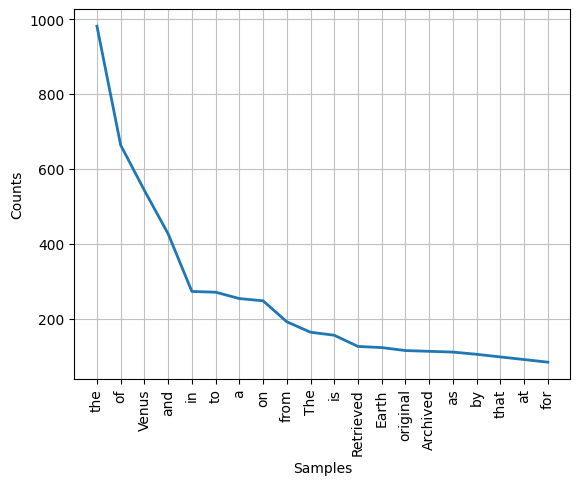

In [65]:
freq.plot(20)

In [66]:
from nltk.corpus import stopwords

In [67]:
swords = stopwords.words('english')

In [68]:
swords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [76]:
swords.extend(['Retrieved','Archived','retrieved','archived'])

In [78]:
tokens3 = [token.lower() for token in tokens2 if token.lower() not in swords]

<Axes: xlabel='Samples', ylabel='Counts'>

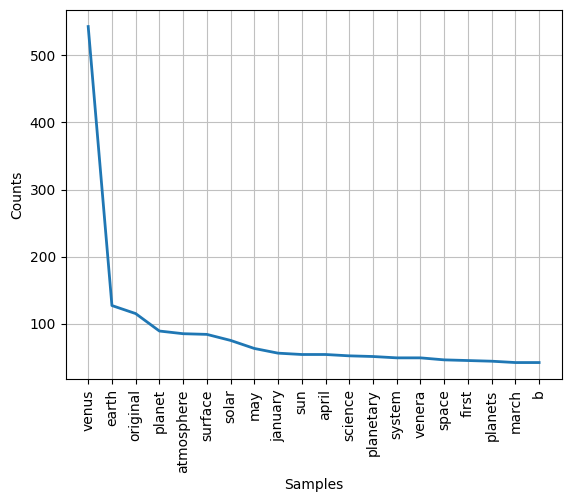

In [79]:
# create the object 
freq = FreqDist(tokens3)
freq.plot(20)